<a href="https://colab.research.google.com/github/zahrae12/JobPortalWebsite/blob/main/trash_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
from pathlib import Path

# Base directory for organized data
base_dir = Path('/content/trash_dataset')
train_dir = base_dir / 'train'
classes = ['plastic', 'paper', 'glass', 'cardboard', 'metal']

# Create folder structure: train/class_name/
for class_name in classes:
    (train_dir / class_name).mkdir(parents=True, exist_ok=True)

print("Folders created at /content/trash_dataset/train/")


Folders created at /content/trash_dataset/train/


In [ ]:
# Assume your pics are in /content/images/ (upload them there first via drag-drop or !unzip)
source_dir = Path('/content/images')  # Change if your flat folder differs

def get_class(filename):
    fname_lower = filename.lower()
    if any(word in fname_lower for word in ['plastic', 'plast']): return 'plastic'
    if any(word in fname_lower for word in ['paper', 'papier']): return 'paper'
    if any(word in fname_lower for word in ['glass', 'verre']): return 'glass'
    if any(word in fname_lower for word in ['cardboard', 'carton', 'card']): return 'cardboard'
    if any(word in fname_lower for word in ['metal', 'métal']): return 'metal'
    return None  # Unclassified

moved_count = 0
for img_path in source_dir.glob('*.[jJ][pP][gG]'):  # Add .png, .jpg variants as needed
    img_path = img_path.resolve()
    class_name = get_class(img_path.name)
    if class_name:
        dest_path = train_dir / class_name / img_path.name
        shutil.copy2(img_path, dest_path)  # Use copy2 to preserve metadata
        moved_count += 1
        print(f"Moved {img_path.name} -> {class_name}/")

print(f"Organized {moved_count} images into /content/trash_dataset/train/")


Organized 0 images into /content/trash_dataset/train/


In [ ]:
import os
from pathlib import Path

content_dir = Path('/content')
print("Contents of /content/:")
for item in content_dir.iterdir():
    print(f"  {item.name} (dir: {item.is_dir()})")

# List all image files recursively
images = list(content_dir.rglob('*.[jJ][pP][gG]')) + list(content_dir.rglob('*.[pP][nN][gG]'))
print(f"\nFound {len(images)} images:")
for img in images[:10]:  # Show first 10
    print(f"  {img}")
if len(images) > 10:
    print("  ... and more")


Contents of /content/:
  .config (dir: True)
  metal104.jpg (dir: False)
  glass48.jpg (dir: False)
  glass296.jpg (dir: False)
  paper537.jpg (dir: False)
  paper51.jpg (dir: False)
  paper568.jpg (dir: False)
  cardboard70.jpg (dir: False)
  cardboard318.jpg (dir: False)
  glass455.jpg (dir: False)
  glass58.jpg (dir: False)
  plastic449.jpg (dir: False)
  glass214.jpg (dir: False)
  paper60.jpg (dir: False)
  paper450.jpg (dir: False)
  plastic157.jpg (dir: False)
  paper138.jpg (dir: False)
  plastic382.jpg (dir: False)
  paper545.jpg (dir: False)
  paper511.jpg (dir: False)
  paper394.jpg (dir: False)
  cardboard20.jpg (dir: False)
  cardboard123.jpg (dir: False)
  plastic421.jpg (dir: False)
  glass186.jpg (dir: False)
  metal371.jpg (dir: False)
  metal292.jpg (dir: False)
  glass326.jpg (dir: False)
  paper542.jpg (dir: False)
  plastic374.jpg (dir: False)
  glass12.jpg (dir: False)
  metal315.jpg (dir: False)
  plastic150.jpg (dir: False)
  glass269.jpg (dir: False)
  paper386

In [ ]:
import shutil
from pathlib import Path

# Create folder structure
base_dir = Path('/content/trash_dataset')
train_dir = base_dir / 'train'
classes = ['plastic', 'paper', 'glass', 'cardboard', 'metal']

for class_name in classes:
    (train_dir / class_name).mkdir(parents=True, exist_ok=True)

# Source is /content/ - your images are directly there!
source_dir = Path('/content')

# Simple exact match classifier for your filenames
def get_class(filename):
    name_lower = filename.lower()
    if 'plastic' in name_lower: return 'plastic'
    if 'paper' in name_lower: return 'paper'
    if 'glass' in name_lower: return 'glass'
    if 'cardboard' in name_lower: return 'cardboard'
    if 'metal' in name_lower: return 'metal'
    return None

# Move ALL your images
moved = 0
for img_path in source_dir.glob('*.jpg'):
    class_name = get_class(img_path.name)
    if class_name:
        dest_path = train_dir / class_name / img_path.name
        shutil.move(img_path, dest_path)  # Use move since they're already in /content/
        moved += 1
        print(f"✓ {img_path.name} → {class_name}/")

print(f"\n🎉 Successfully organized {moved} images!")


✓ metal104.jpg → metal/
✓ glass48.jpg → glass/
✓ glass296.jpg → glass/
✓ paper537.jpg → paper/
✓ paper51.jpg → paper/
✓ paper568.jpg → paper/
✓ cardboard70.jpg → cardboard/
✓ cardboard318.jpg → cardboard/
✓ glass455.jpg → glass/
✓ glass58.jpg → glass/
✓ plastic449.jpg → plastic/
✓ glass214.jpg → glass/
✓ paper60.jpg → paper/
✓ paper450.jpg → paper/
✓ plastic157.jpg → plastic/
✓ paper138.jpg → paper/
✓ plastic382.jpg → plastic/
✓ paper545.jpg → paper/
✓ paper511.jpg → paper/
✓ paper394.jpg → paper/
✓ cardboard20.jpg → cardboard/
✓ cardboard123.jpg → cardboard/
✓ plastic421.jpg → plastic/
✓ glass186.jpg → glass/
✓ metal371.jpg → metal/
✓ metal292.jpg → metal/
✓ glass326.jpg → glass/
✓ paper542.jpg → paper/
✓ plastic374.jpg → plastic/
✓ glass12.jpg → glass/
✓ metal315.jpg → metal/
✓ plastic150.jpg → plastic/
✓ glass269.jpg → glass/
✓ paper386.jpg → paper/
✓ glass97.jpg → glass/
✓ cardboard121.jpg → cardboard/
✓ cardboard196.jpg → cardboard/
✓ paper454.jpg → paper/
✓ glass105.jpg → glass/


In [ ]:
for class_name in classes:
    count = len(list((train_dir / class_name).glob('*.jpg')))
    print(f"{class_name:10}: {count} images")


plastic   : 482 images
paper     : 594 images
glass     : 501 images
cardboard : 403 images
metal     : 410 images


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# 1. Load your data (automatically splits train/val)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder('/content/trash_dataset/train', transform=transform)
train_size = int(0.8 * len(dataset))  # 80% train
val_size = len(dataset) - train_size   # 20% validation
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"✅ Train: {len(train_ds)}, Val: {len(val_ds)} images")
print(f"Classes: {dataset.classes}")


✅ Train: 1912, Val: 478 images
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import Adam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Create model (ResNet18 pretrained)
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 5)  # 5 trash classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# Train for 10 epochs
for epoch in range(10):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:  # Uses your loaded data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/10: Loss={running_loss/len(train_loader):.3f}, "
          f"Accuracy={100.*correct/total:.1f}%")

torch.save(model.state_dict(), '/content/trash_classifier.pth')
print("🎉 Model trained and saved!")


Using: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


Epoch 1/10: Loss=0.867, Accuracy=74.7%
Epoch 2/10: Loss=0.536, Accuracy=67.2%
Epoch 3/10: Loss=0.430, Accuracy=79.9%
Epoch 4/10: Loss=0.332, Accuracy=81.6%
Epoch 5/10: Loss=0.237, Accuracy=80.5%
Epoch 6/10: Loss=0.200, Accuracy=83.1%
Epoch 7/10: Loss=0.133, Accuracy=76.2%
Epoch 8/10: Loss=0.156, Accuracy=80.1%
Epoch 9/10: Loss=0.151, Accuracy=79.3%
Epoch 10/10: Loss=0.124, Accuracy=82.2%
🎉 Model trained and saved!


In [ ]:
# Continue training from your saved model (more epochs, better loop)
model.load_state_dict(torch.load('/content/trash_classifier.pth'))

# Lower learning rate for fine-tuning
optimizer = Adam(model.parameters(), lr=0.0001)

for epoch in range(10, 20):  # Continue from epoch 10
    model.train()
    running_loss = 0.0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Print progress every 10 batches
        if batch_idx % 10 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.3f}')

    # Full validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Epoch {epoch+1}/20: Loss={running_loss/len(train_loader):.3f}, '
          f'Accuracy={100.*correct/total:.2f}%')

torch.save(model.state_dict(), '/content/trash_classifier_v2.pth')
print("🎉 Improved model saved!")


Epoch 11, Batch 0, Loss: 0.044
Epoch 11, Batch 10, Loss: 0.022
Epoch 11, Batch 20, Loss: 0.011
Epoch 11, Batch 30, Loss: 0.150
Epoch 11, Batch 40, Loss: 0.017
Epoch 11, Batch 50, Loss: 0.064
Epoch 11/20: Loss=0.048, Accuracy=88.49%
Epoch 12, Batch 0, Loss: 0.002
Epoch 12, Batch 10, Loss: 0.018
Epoch 12, Batch 20, Loss: 0.043
Epoch 12, Batch 30, Loss: 0.006
Epoch 12, Batch 40, Loss: 0.004
Epoch 12, Batch 50, Loss: 0.014
Epoch 12/20: Loss=0.017, Accuracy=90.38%
Epoch 13, Batch 0, Loss: 0.002
Epoch 13, Batch 10, Loss: 0.011
Epoch 13, Batch 20, Loss: 0.003
Epoch 13, Batch 30, Loss: 0.028
Epoch 13, Batch 40, Loss: 0.001
Epoch 13, Batch 50, Loss: 0.002
Epoch 13/20: Loss=0.008, Accuracy=90.59%
Epoch 14, Batch 0, Loss: 0.005
Epoch 14, Batch 10, Loss: 0.041
Epoch 14, Batch 20, Loss: 0.001
Epoch 14, Batch 30, Loss: 0.010
Epoch 14, Batch 40, Loss: 0.007
Epoch 14, Batch 50, Loss: 0.004
Epoch 14/20: Loss=0.007, Accuracy=89.33%
Epoch 15, Batch 0, Loss: 0.002
Epoch 15, Batch 10, Loss: 0.003
Epoch 15,

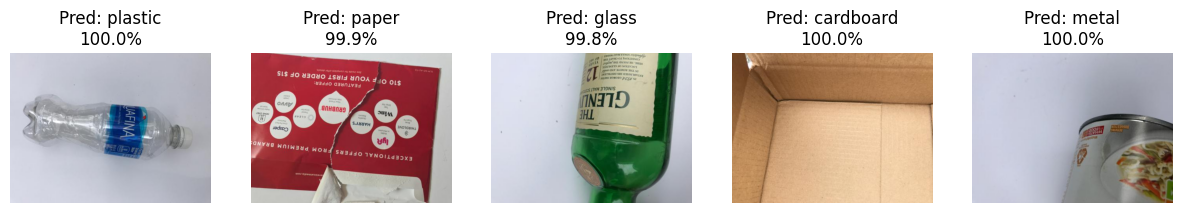

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

model.load_state_dict(torch.load('/content/trash_classifier_v2.pth'))
model.eval()

# Test 5 random images
test_paths = [
    '/content/trash_dataset/train/plastic/plastic49.jpg',
    '/content/trash_dataset/train/paper/paper56.jpg',
    '/content/trash_dataset/train/glass/glass154.jpg',
    '/content/trash_dataset/train/cardboard/cardboard55.jpg',
    '/content/trash_dataset/train/metal/metal59.jpg'
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, img_path in enumerate(test_paths):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, 1)
        pred_idx = torch.argmax(probs, 1).item()
        confidence = probs[0][pred_idx].item()
        pred_name = dataset.classes[pred_idx]

    axes[i].imshow(img)
    axes[i].set_title(f'Pred: {pred_name}\n{confidence:.1%}')
    axes[i].axis('off')
plt.show()


In [ ]:
# Save for mobile/web deployment
torch.save(model.state_dict(), '/content/drive/MyDrive/trash_classifier_final.pth')

# Export to ONNX (works everywhere)
torch.onnx.export(model, torch.randn(1, 3, 224, 224).to(device),
                  '/content/trash_classifier.onnx', opset_version=11)


RuntimeError: Parent directory /content/drive/MyDrive does not exist.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Now this will work!
torch.save(model.state_dict(), '/content/drive/MyDrive/trash_classifier_final.pth')
print("✅ Saved to Google Drive!")

# Also save ONNX for mobile/web
dummy_input = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(model, dummy_input, '/content/drive/MyDrive/trash_classifier.onnx')
print("✅ ONNX exported to Google Drive!")


✅ Saved to Google Drive!


ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
def predict_trash(img_path):
    """Use anywhere - copy this function!"""
    model.load_state_dict(torch.load('/content/trash_classifier_v2.pth'))
    model.eval()

    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(img_tensor), 1)[0]
        pred_class = dataset.classes[torch.argmax(probs).item()]
        confidence = probs.max().item()

    return pred_class, confidence

# Test it
print(predict_trash('/content/trash_dataset/train/plastic/plastic49.jpg'))


('plastic', 0.9999958276748657)


In [ ]:
import streamlit as st
import torch
from PIL import Image
from torchvision import models, transforms

# Load your model
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load('trash_classifier_v2.pth'))
model.eval()

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

st.title("🗑️ Trash Classifier (91.6% accuracy)")
uploaded = st.file_uploader("Upload trash photo")
if uploaded:
    img = Image.open(uploaded).convert('RGB')
    img_t = transform(img).unsqueeze(0)
    pred = classes[torch.argmax(torch.softmax(model(img_t), 1)).item()]
    st.image(img, caption=f"Prediction: **{pred}**")


ModuleNotFoundError: No module named 'streamlit'

In [ ]:
!pip install streamlit pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 138.1 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


In [ ]:
%%writefile trash_app.py
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

# Load your 91.6% accurate model
@st.cache_resource
def load_model():
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 5)
    model.load_state_dict(torch.load('/content/trash_classifier_v2.pth'))
    model.eval()
    return model

# Your trained classes
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

st.title("🗑️ Trash Classifier AI")
st.write("**91.6% accurate** - Upload any trash photo!")

model = load_model()
uploaded_file = st.file_uploader("Choose a trash photo...", type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption="Uploaded Image", use_column_width=True)

    # Predict
    img_array = np.array(image)
    img_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence = torch.max(probabilities).item()
        predicted_class = classes[torch.argmax(probabilities).item()]

    st.success(f"**Prediction: {predicted_class}** ({confidence:.1%} confidence)")
    st.write("**All probabilities:**")
    for i, (class_name, prob) in enumerate(zip(classes, probabilities)):
        st.write(f"- {class_name}: {prob:.1%}")


Writing trash_app.py


In [ ]:
# 1. Install localtunnel (for public URL)
!npm install localtunnel -q


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [ ]:
# 2. Start Streamlit + get public URL
!streamlit run trash_app.py &>/content/logs.txt &
!npx localtunnel --port 8501


⠙⠹your url is: https://famous-deer-eat.loca.lt
^C


In [ ]:
!curl ipv4.icanhazip.com


34.87.143.191


In [ ]:
from google.colab import files
import torch
from PIL import Image

uploaded = files.upload()  # CLICK HERE TO UPLOAD
model.eval()

for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(img_tensor), 1)[0]
        pred = dataset.classes[torch.argmax(probs).item()]
        conf = probs.max().item()

    print(f"🗑️ {filename}: **{pred}** ({conf:.1%})")


Saving cardboard2.jpg to cardboard2.jpg
🗑️ cardboard2.jpg: **cardboard** (100.0%)


In [ ]:
!pkill -f streamlit
!pip install streamlit --upgrade
!streamlit run trash_app.py &>/content/logs.txt &
!sleep 10
!npx localtunnel --port 8501


⠙your url is: https://wise-aliens-cheer.loca.lt
